# SensAI: Model Notebook (Stage 2 scaffolding policy)

**Akachi David Nwanze · BSc Software Engineering (ML), African Leadership University**

SensAI is a two-stage system. Stage 1 will map non-invasive telemetry (response time, error rate, hint count, time on task) to a behavioural engagement-risk state for school-age learners aged 8–14. Stage 2 takes that state and picks an instructional scaffolding action with a DQN policy.

This notebook covers **Stage 2 only**, which is the part that exists today. It is trained and evaluated entirely in a simulated environment (`AdaptLearn-v1`, a custom Gymnasium environment). No real learner data is used anywhere in this notebook.

Two things to keep in mind while reading:

- The simulator names its four learner states `FRUSTRATED`, `BORED`, `CONFUSED` and `ENGAGED`. These are labels for simulated states that I defined. SensAI does not claim to detect those emotions in real children. The construct is behavioural engagement (Fredricks et al., 2004), inferred from observable interaction signals.
- Every result here shows how the policy behaves under the simulator's assumptions. It is evidence of internal stability, not of learning gains in a real classroom.

**Contents**

1. Setup
2. Data visualisation and data engineering
3. Model architecture
4. Training results
5. Initial performance metrics
6. Limitations and next phase

Sections 4 and 5 read the logs and models saved by the original training runs (`logs/`, `models/`). Nothing is retrained here. Cells that generate new data (simulator rollouts, re-evaluation of the saved model) say so and use fixed seeds.

## 1. Setup

In [1]:
import json
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from stable_baselines3 import DQN

from environment.custom_env import (
    ACTION_NAMES,
    AdaptLearnEnv,
    EngagementState,
    RewardConfig,
)

ROOT = Path.cwd()
assert (ROOT / "logs").exists() and (ROOT / "models").exists(), "Run this notebook from the repository root."

STATE_NAMES = [s.name for s in EngagementState]
STATE_COLORS = {"FRUSTRATED": "#c44e52", "BORED": "#dd8452", "CONFUSED": "#8172b3", "ENGAGED": "#55a868"}
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
pd.set_option("display.precision", 3)

## 2. Data visualisation and data engineering

A supervised model has a fixed dataset. An RL agent does not: its training data is the stream of `(observation, action, reward, next observation)` transitions it collects by interacting with the environment. So the "training data" for Stage 2 is whatever the simulator produces.

To look at that data without any policy shaping it, I roll out a **uniform random policy** for 500 episodes on fixed seeds (9000–9499, not used by any training or evaluation run) and record every step. This is close to what DQN sees early in training, when ε is near 1.

In [2]:
def collect_random_rollouts(seeds):
    rows = []
    rng = np.random.default_rng(0)
    env = AdaptLearnEnv()
    for ep, seed in enumerate(seeds):
        obs, info = env.reset(seed=seed)
        done = False
        while not done:
            state_before = info["engagement_state"]
            action = int(rng.integers(env.action_space.n))
            obs, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            rows.append({
                "episode": ep,
                "step": info["steps"],
                "state_before": state_before,
                "action": ACTION_NAMES[action],
                "state": info["engagement_state"],
                "response_time": float(obs[4]),
                "error_rate": float(obs[5]),
                "hint_count": info["hint_count"],
                "difficulty": info["difficulty"],
                "time_on_task": info["time_on_task"],
                "gap": info["gap"],
                "ability": info["ability"],
                "reward": reward,
                "dropout": info["dropout"],
                "success": info["success"],
            })
    return pd.DataFrame(rows)


data = collect_random_rollouts(range(9000, 9500))
print(f"{len(data):,} transitions from {data['episode'].nunique()} episodes")
data.head()

9,965 transitions from 500 episodes


,episode,step,state_before,action,state,response_time,error_rate,hint_count,difficulty,time_on_task,gap,ability,reward,dropout,success
0,0,1,FRUSTRATED,repeat_simplified,BORED,0.248,0.316,0,2,1,0.032,1.968,-0.52,False,False
1,0,2,BORED,introduce_challenge,ENGAGED,0.471,0.032,0,2,2,0.032,1.968,0.98,False,False
2,0,3,ENGAGED,add_encouragement,ENGAGED,0.360,0.037,0,2,3,0.032,1.968,0.13,False,False
3,0,4,ENGAGED,change_task_type,ENGAGED,0.464,0.058,0,2,4,0.032,1.968,0.13,False,False
4,0,5,ENGAGED,change_task_type,ENGAGED,0.355,0.138,0,2,5,0.032,1.968,0.13,False,False


In [3]:
data[["response_time", "error_rate", "hint_count", "difficulty", "time_on_task", "gap", "reward"]].describe().T

,count,mean,std,min,25%,50%,75%,max
response_time,9965.0,0.484,0.118,0.131,0.409,0.470,0.545,0.925
error_rate,9965.0,0.224,0.183,0.000,0.091,0.177,0.296,0.906
hint_count,9965.0,0.731,1.127,0.000,0.000,0.000,1.000,11.000
difficulty,9965.0,3.806,1.281,1.000,3.000,4.000,5.000,5.000
time_on_task,9965.0,5.345,5.879,0.000,1.000,3.000,7.000,50.000
gap,9965.0,0.525,1.347,-3.965,-0.271,0.609,1.416,4.000
reward,9965.0,-0.052,0.834,-3.020,-0.520,0.130,0.130,1.480


### 2.1 How often each simulated state occurs

`CONFUSED` is the rarest state by a wide margin. This matters later: the trained policies handle `CONFUSED` worst, and part of the reason is simply that they see it least.

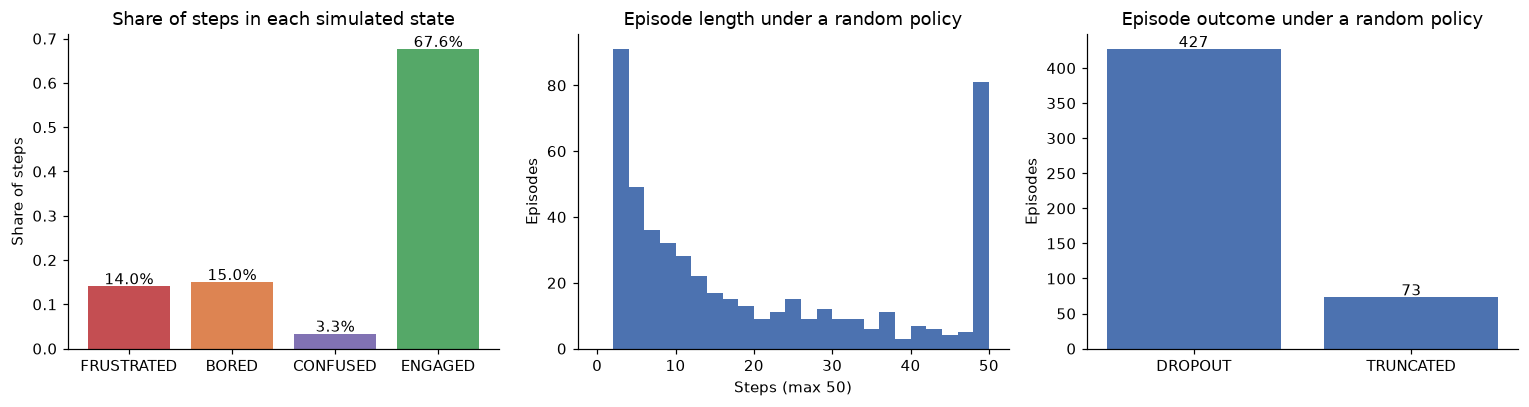

state
FRUSTRATED    0.140
BORED         0.150
CONFUSED      0.033
ENGAGED       0.676


In [4]:
ep_len = data.groupby("episode")["step"].max()
outcome = data.groupby("episode")[["dropout", "success"]].max()
outcome_label = np.where(outcome["dropout"], "DROPOUT", np.where(outcome["success"], "SUCCESS", "TRUNCATED"))

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))

share = data["state"].value_counts(normalize=True).reindex(STATE_NAMES)
axes[0].bar(share.index, share.values, color=[STATE_COLORS[s] for s in share.index])
for i, v in enumerate(share.values):
    axes[0].text(i, v + 0.005, f"{v:.1%}", ha="center")
axes[0].set_title("Share of steps in each simulated state")
axes[0].set_ylabel("Share of steps")

axes[1].hist(ep_len, bins=range(0, 52, 2), color="#4c72b0")
axes[1].set_title("Episode length under a random policy")
axes[1].set_xlabel("Steps (max 50)")
axes[1].set_ylabel("Episodes")

oc = pd.Series(outcome_label).value_counts()
axes[2].bar(oc.index, oc.values, color="#4c72b0")
for i, v in enumerate(oc.values):
    axes[2].text(i, v + 3, str(v), ha="center")
axes[2].set_title("Episode outcome under a random policy")
axes[2].set_ylabel("Episodes")
plt.tight_layout()
plt.show()
print(share.round(3).to_string())

### 2.2 Telemetry distributions by state

These are the four telemetry features the policy observes. The question is whether they carry any signal about the state, because in the full system Stage 1 has to infer the state from exactly these signals.

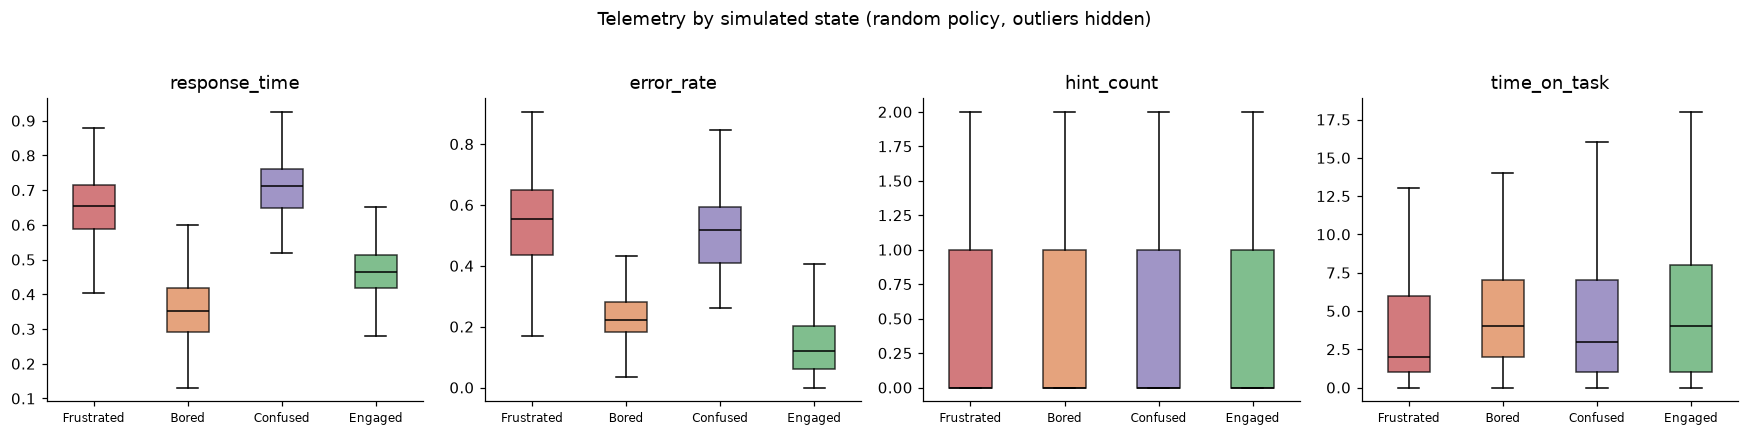

,response_time,error_rate,hint_count,time_on_task,gap
state,,,,,
FRUSTRATED,0.651,0.538,0.573,4.204,1.813
BORED,0.358,0.248,0.779,5.456,-0.653
CONFUSED,0.707,0.509,0.747,5.533,1.013
ENGAGED,0.467,0.139,0.753,5.548,0.495


In [5]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3.8))
for ax, col in zip(axes, ["response_time", "error_rate", "hint_count", "time_on_task"]):
    groups = [data.loc[data["state"] == s, col] for s in STATE_NAMES]
    bp = ax.boxplot(groups, tick_labels=[s.title() for s in STATE_NAMES], patch_artist=True, showfliers=False)
    for patch, s in zip(bp["boxes"], STATE_NAMES):
        patch.set_facecolor(STATE_COLORS[s])
        patch.set_alpha(0.75)
    for med in bp["medians"]:
        med.set_color("black")
    ax.set_title(col)
    ax.tick_params(axis="x", labelsize=8)
plt.suptitle("Telemetry by simulated state (random policy, outliers hidden)", y=1.03)
plt.tight_layout()
plt.show()

data.groupby("state")[["response_time", "error_rate", "hint_count", "time_on_task", "gap"]].mean().reindex(STATE_NAMES)

Response time and error rate separate the states (slow and error-prone for `CONFUSED`, fast for `BORED`). That separation is built into the simulator through per-state offsets in `TransitionConfig`, so it is an assumption, not a finding about real learners. Whether real telemetry separates engagement-risk states this cleanly is the question Stage 1 and the pilot have to answer.

### 2.3 Correlations

`gap` (difficulty minus the learner's hidden ability) is included for analysis only. The policy never sees it.

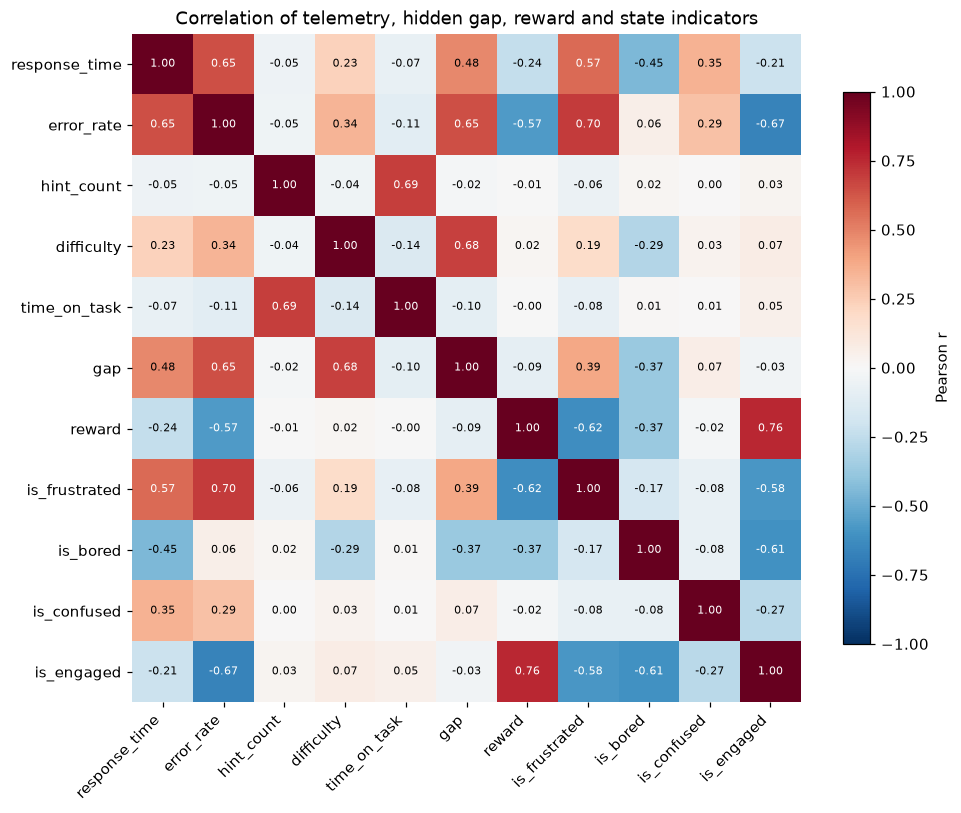

In [6]:
corr_cols = ["response_time", "error_rate", "hint_count", "difficulty", "time_on_task", "gap", "reward"]
corr_df = data[corr_cols].copy()
for s in STATE_NAMES:
    corr_df[f"is_{s.lower()}"] = (data["state"] == s).astype(int)
corr = corr_df.corr()

fig, ax = plt.subplots(figsize=(9, 7.5))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr)))
ax.set_yticklabels(corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        v = corr.iloc[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7, color="white" if abs(v) > 0.55 else "black")
fig.colorbar(im, ax=ax, shrink=0.8, label="Pearson r")
ax.set_title("Correlation of telemetry, hidden gap, reward and state indicators")
ax.spines[:].set_visible(False)
plt.tight_layout()
plt.show()

### 2.4 Which actions help from which state

Share of steps that end in `ENGAGED`, by the state the learner was in and the action taken (random policy, so every pair is sampled). This is the structure the agent has to discover from reward alone.

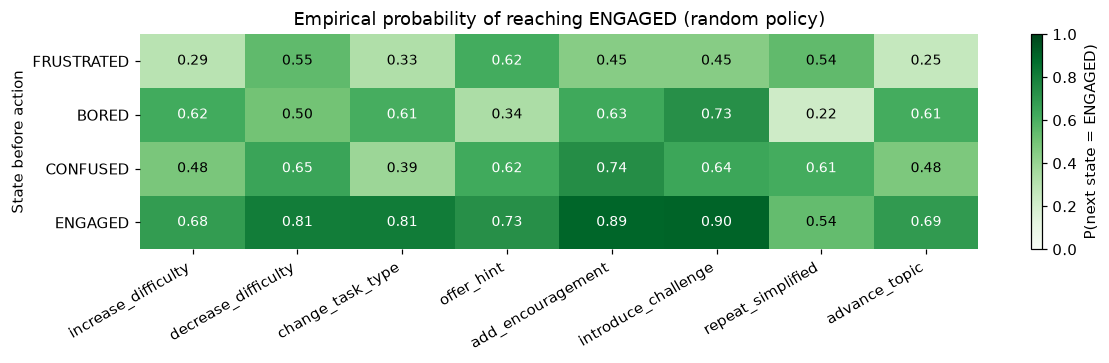

Transitions per cell (state before x action):


action,increase_difficulty,decrease_difficulty,change_task_type,offer_hint,add_encouragement,introduce_challenge,repeat_simplified,advance_topic
state_before,,,,,,,,
FRUSTRATED,150,169,163,174,154,147,182,157
BORED,193,176,177,156,168,157,186,184
CONFUSED,54,63,62,56,58,53,57,61
ENGAGED,878,840,823,820,895,858,857,837


In [7]:
to_engaged = (
    data.assign(engaged=data["state"] == "ENGAGED")
    .pivot_table(index="state_before", columns="action", values="engaged", aggfunc="mean")
    .reindex(index=STATE_NAMES, columns=list(ACTION_NAMES))
)

fig, ax = plt.subplots(figsize=(11, 3.4))
im = ax.imshow(to_engaged, cmap="Greens", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(len(ACTION_NAMES)))
ax.set_xticklabels(ACTION_NAMES, rotation=30, ha="right")
ax.set_yticks(range(4))
ax.set_yticklabels(STATE_NAMES)
for i in range(4):
    for j in range(len(ACTION_NAMES)):
        v = to_engaged.iloc[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=9, color="white" if v > 0.6 else "black")
fig.colorbar(im, ax=ax, label="P(next state = ENGAGED)")
ax.set_ylabel("State before action")
ax.set_title("Empirical probability of reaching ENGAGED (random policy)")
ax.spines[:].set_visible(False)
plt.tight_layout()
plt.show()
print("Transitions per cell (state before x action):")
pd.crosstab(data["state_before"], data["action"]).reindex(index=STATE_NAMES, columns=list(ACTION_NAMES))

The `CONFUSED` row rests on few transitions per cell, so differences of a few points within it are noise.

### 2.5 Data engineering: the observation vector

The policy input is a 9-dimensional vector, every entry in [0, 1]:

| Index | Feature | Engineering |
|---|---|---|
| 0–3 | Engagement state | One-hot in the order `FRUSTRATED, BORED, CONFUSED, ENGAGED`. The states are nominal, so a single index would imply distances that do not exist. |
| 4 | Response time | Simulated, clipped to [0, 1] |
| 5 | Error rate | Simulated, clipped to [0, 1] |
| 6 | Hint count on current task | `min(1, count / 5)` |
| 7 | Difficulty level | `(level − 1) / 4`, levels 1–5 |
| 8 | Time on current task | `min(1, steps / 10)` |

The learner's ability is hidden, so the task is partially observable. Reward shaping is part of the data too, since reward is the only supervision the agent gets:

In [8]:
env = AdaptLearnEnv()
print("Observation space:", env.observation_space)
print("Action space:     ", env.action_space, "->", list(ACTION_NAMES))
obs, info = env.reset(seed=2)
print("\nExample observation (seed=2):", np.round(obs, 3), "| state:", info["engagement_state"])

pd.Series(vars(RewardConfig()), name="value").to_frame()

Observation space: Box(0.0, 1.0, (9,), float32)
Action space:      Discrete(8) -> ['increase_difficulty', 'decrease_difficulty', 'change_task_type', 'offer_hint', 'add_encouragement', 'introduce_challenge', 'repeat_simplified', 'advance_topic']

Example observation (seed=2): [0.    1.    0.    0.    0.206 0.179 0.    0.    0.   ] | state: BORED


,value
engaged_reach_reward,1.00
engaged_maintain_reward,0.15
frustrated_step_reward,-1.00
bored_step_reward,-0.50
confused_step_reward,-0.20
dropout_terminal_penalty,-2.00
session_complete_bonus,5.00
topic_advance_bonus,0.50
step_cost,-0.02


## 3. Model architecture

The deployed policy is the best DQN run from a 12-configuration hyperparameter sweep (`dqn_02`). I load the saved model and read the architecture off it directly, so what is printed below is what actually runs behind the API.

In [9]:
best = json.loads((ROOT / "logs/dqn/best_run.json").read_text())
model = DQN.load(ROOT / best["model_path"], device="cpu")

print("Best run:", best["run_id"], "| seed:", best["seed"])
print("\nOnline Q-network:\n")
print(model.q_net)
n_params = sum(p.numel() for p in model.q_net.parameters())
print(f"\nTrainable parameters in the Q-network: {n_params:,}")

Best run: dqn_02 | seed: 1002

Online Q-network:

QNetwork(
  (features_extractor): FlattenExtractor(
    (flatten): Flatten(start_dim=1, end_dim=-1)
  )
  (q_net): Sequential(
    (0): Linear(in_features=9, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=8, bias=True)
  )
)

Trainable parameters in the Q-network: 5,320


In [10]:
arch = pd.Series({
    "Input": "9-dim observation (Section 2.5)",
    "Hidden layers": " -> ".join(str(n) for n in best["hyperparams"]["net_arch"]) + " fully connected",
    "Hidden activation": model.policy.activation_fn.__name__,
    "Output": f"{model.action_space.n} linear units, one Q-value per action",
    "Optimizer": type(model.policy.optimizer).__name__,
    "Learning rate": model.learning_rate,
    "Loss": "Huber (smooth L1) on the TD error",
    "Discount factor (gamma)": model.gamma,
    "Replay buffer size": model.buffer_size,
    "Batch size": model.batch_size,
    "Learning starts after (steps)": model.learning_starts,
    "Train frequency": f"1 gradient step every {model.train_freq.frequency} environment steps",
    "Target network update interval (steps)": model.target_update_interval,
    "Soft update coefficient (tau)": model.tau,
    "Exploration": f"epsilon-greedy, {model.exploration_initial_eps} -> {model.exploration_final_eps} "
                   f"over the first {model.exploration_fraction:.0%} of training",
    "Gradient clipping (max norm)": model.max_grad_norm,
    "Training budget": "20,000 environment steps",
}, name="dqn_02").astype(str)
with pd.option_context("display.max_colwidth", None):
    display(arch.to_frame())

,dqn_02
Input,9-dim observation (Section 2.5)
Hidden layers,64 -> 64 fully connected
Hidden activation,ReLU
Output,"8 linear units, one Q-value per action"
Optimizer,Adam
Learning rate,0.0005
Loss,Huber (smooth L1) on the TD error
Discount factor (gamma),0.95
Replay buffer size,20000
Batch size,64


**How the pieces fit together**

- **Q-network.** A small multilayer perceptron that maps the observation to eight Q-values. The action with the highest Q-value is the scaffolding action the policy recommends.
- **Experience replay.** Transitions are stored in a buffer and sampled in random minibatches, which breaks the correlation between consecutive steps of the same episode.
- **Target network.** A periodically synced copy of the Q-network provides the bootstrap target `r + γ · max Q_target(s', a')`, which keeps the regression target from moving on every gradient step.
- **Huber loss with Adam and gradient clipping.** Huber behaves like squared error for small TD errors and like absolute error for large ones, so occasional large errors (for example the −2 dropout penalty) do not dominate an update.
- **ε-greedy exploration.** The agent starts fully random and anneals towards mostly greedy actions.

DQN was chosen over the policy-gradient methods on results, not in advance. PPO, A2C and a from-scratch REINFORCE were trained on the same environment with the same budget (Section 4.2).

## 4. Training results

Everything in this section is read from the logs written by the original training runs.

### 4.1 DQN hyperparameter sweep

Twelve configurations, 20,000 steps each. `final_mean_reward` is the mean reward of the last 20 training episodes. `best_mean_reward` is the highest 20-episode rolling mean reached at any point.

In [11]:
sweep = pd.read_csv(ROOT / "logs/dqn/runs_summary.csv")
show = sweep[["run_id", "seed", "n_episodes", "final_mean_reward", "best_mean_reward",
              "hp_learning_rate", "hp_gamma", "hp_batch_size", "hp_net_arch", "hp_buffer_size",
              "hp_exploration_fraction", "hp_target_update_interval"]]
show.sort_values("final_mean_reward", ascending=False).reset_index(drop=True)

,run_id,seed,n_episodes,final_mean_reward,best_mean_reward,hp_learning_rate,hp_gamma,hp_batch_size,hp_net_arch,hp_buffer_size,hp_exploration_fraction,hp_target_update_interval
0,dqn_02,1002,579,9.659,9.659,5.000e-04,0.950,64,"[64, 64]",20000,0.20,500
1,dqn_08,1008,578,8.694,9.718,7.000e-04,0.970,64,"[64, 64, 64]",20000,0.30,500
2,dqn_09,1009,512,7.944,9.227,1.000e-03,0.990,64,"[64, 64]",20000,0.10,500
3,dqn_10,1010,549,7.870,9.540,3.000e-04,0.995,64,"[128, 64]",30000,0.30,750
4,dqn_00,1000,572,7.416,8.476,1.000e-03,0.990,32,"[64, 64]",10000,0.30,500
5,dqn_03,1003,545,6.803,8.893,5.000e-04,0.990,64,"[128, 128]",20000,0.20,250
6,dqn_11,1011,564,6.723,9.617,1.000e-03,0.990,256,"[64, 64]",20000,0.30,500
7,dqn_04,1004,569,6.368,10.318,1.000e-03,0.900,32,"[64, 64]",10000,0.40,500
8,dqn_05,1005,556,5.361,9.499,1.000e-03,0.990,128,"[128, 128]",50000,0.30,1000
9,dqn_07,1007,620,4.689,6.634,1.000e-03,0.990,32,"[32, 32]",5000,0.30,200


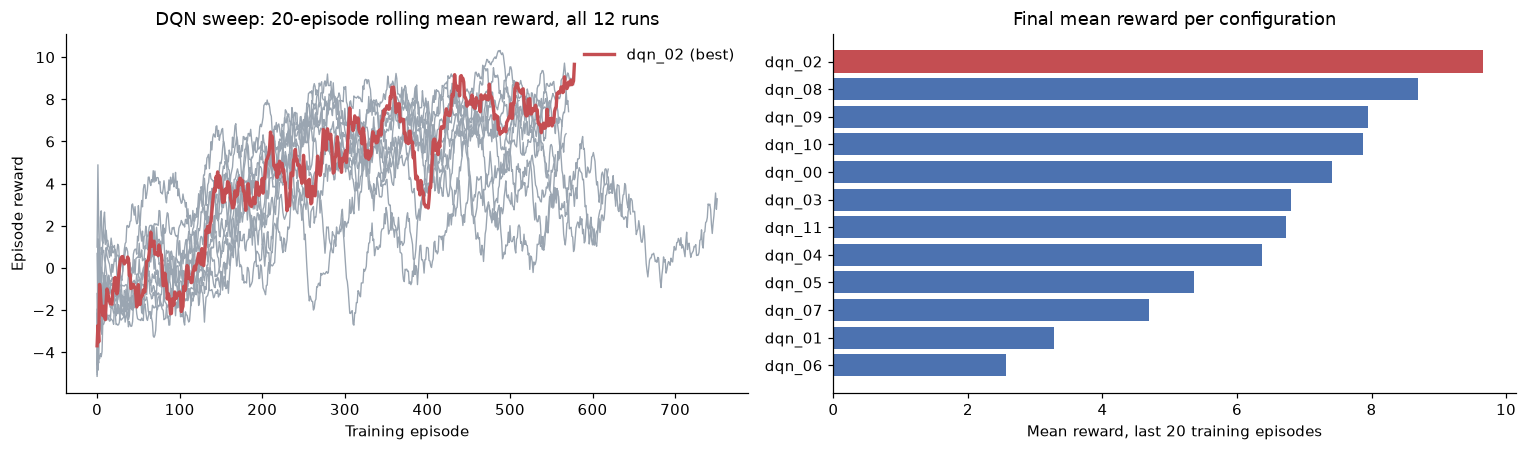

Sweep final mean reward: mean 6.45, std 2.14, min 2.56, max 9.66


In [12]:
def load_run(run_id):
    return json.loads((ROOT / f"logs/dqn/{run_id}/run_result.json").read_text())


fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
for run_id in sweep["run_id"]:
    r = pd.Series(load_run(run_id)["episode_rewards"]).rolling(20, min_periods=1).mean()
    is_best = run_id == best["run_id"]
    axes[0].plot(r, color="#c44e52" if is_best else "#9aa5b1", lw=2.2 if is_best else 0.9,
                 zorder=3 if is_best else 1, label=f"{run_id} (best)" if is_best else None)
axes[0].set_title("DQN sweep: 20-episode rolling mean reward, all 12 runs")
axes[0].set_xlabel("Training episode")
axes[0].set_ylabel("Episode reward")
axes[0].legend(frameon=False)

order = sweep.sort_values("final_mean_reward")
axes[1].barh(order["run_id"], order["final_mean_reward"],
             color=["#c44e52" if r == best["run_id"] else "#4c72b0" for r in order["run_id"]])
axes[1].set_title("Final mean reward per configuration")
axes[1].set_xlabel("Mean reward, last 20 training episodes")
plt.tight_layout()
plt.show()

print(f"Sweep final mean reward: mean {sweep['final_mean_reward'].mean():.2f}, "
      f"std {sweep['final_mean_reward'].std():.2f}, "
      f"min {sweep['final_mean_reward'].min():.2f}, max {sweep['final_mean_reward'].max():.2f}")

The spread across configurations is wide (2.56 to 9.66), and each configuration was run with one seed. So the sweep shows that DQN is sensitive to its hyperparameters here, and the ranking of individual configurations should not be over-read.

### 4.2 Comparison with policy-gradient baselines

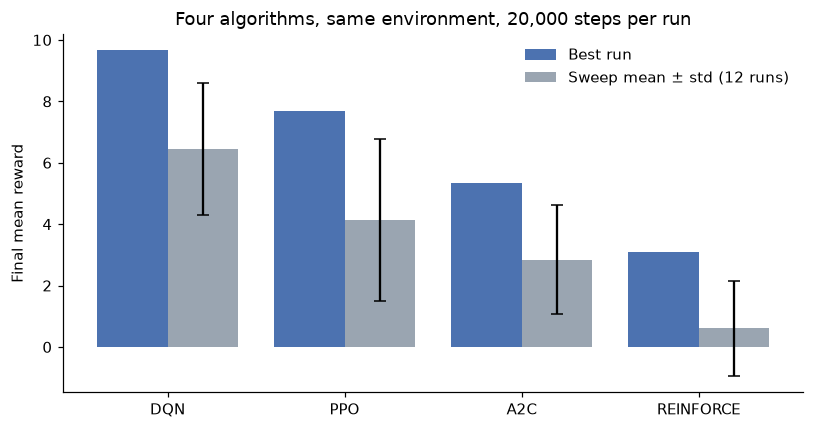

,algo,best_run_id,best_final_mean_reward,sweep_mean_final_mean_reward,sweep_std_final_mean_reward,sweep_min_final_mean_reward,total_timesteps_per_run,mean_training_time_seconds
0,DQN,dqn_02,9.659,6.447,2.136,2.560,20000,4.92
1,PPO,ppo_11,7.675,4.133,2.651,-1.060,20000,6.39
2,A2C,a2c_07,5.325,2.838,1.771,-0.905,20000,6.63
3,REINFORCE,reinforce_00,3.078,0.602,1.540,-1.450,20000,4.07


In [13]:
comp = pd.read_csv(ROOT / "logs/comparison/comparison_table.csv")

fig, ax = plt.subplots(figsize=(7.5, 4))
x = np.arange(len(comp))
ax.bar(x - 0.2, comp["best_final_mean_reward"], 0.4, label="Best run", color="#4c72b0")
ax.bar(x + 0.2, comp["sweep_mean_final_mean_reward"], 0.4, yerr=comp["sweep_std_final_mean_reward"],
       capsize=4, label="Sweep mean ± std (12 runs)", color="#9aa5b1")
ax.set_xticks(x)
ax.set_xticklabels(comp["algo"])
ax.set_ylabel("Final mean reward")
ax.set_title("Four algorithms, same environment, 20,000 steps per run")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()
comp

## 5. Initial performance metrics

### 5.1 Why not accuracy, precision, recall and F1

Those metrics compare predictions against ground-truth labels. Stage 2 has no labels: there is no single "correct" scaffolding action for a given step, only a reward that arrives over the whole episode. Scoring the policy against a hand-written list of "right" actions would mean grading it against my own assumptions twice.

The equivalent questions for an RL policy, and the metric used for each:

| Question | Classification analogue | Metric used here |
|---|---|---|
| How good is the policy? | Accuracy / F1 | Mean episode reward, and episode outcomes (success / truncated / dropout) |
| Did training settle? | Loss curve | Convergence episode, TD-loss curve |
| Does it hold up on unseen data? | Test-set score | Mean reward on held-out seeds, edge-case starts |
| Are the decisions sensible? | Confusion matrix | State × action table of the trained policy |

Accuracy, precision, recall and F1 are the right metrics for **Stage 1** (the engagement-risk classifier), and will be reported there once real pilot data exists.

### 5.2 Convergence

Convergence episode is the first episode at which the 20-episode rolling mean reaches 90% of its peak.

,algo,n_episodes,peak_value,peak_episode,threshold_90pct,converged_episode,converged_value,final_value
0,DQN (dqn_02),579,9.659,578,8.693,433,9.168,9.659
1,PPO (ppo_11),648,8.998,549,8.098,543,8.627,7.675
2,A2C (a2c_07),743,6.840,672,6.156,618,6.539,5.325
3,REINFORCE (reinforce_00),844,3.943,801,3.549,799,3.797,3.078


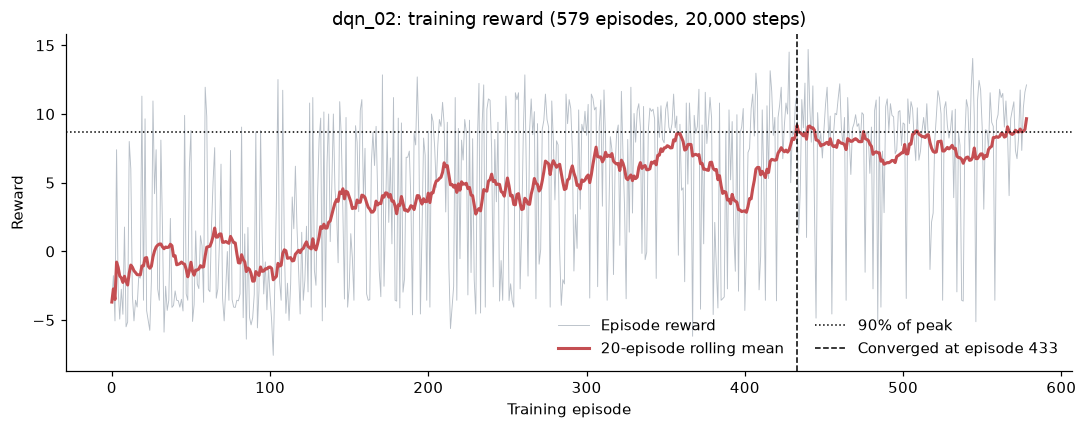

In [14]:
conv = pd.read_csv(ROOT / "logs/comparison/convergence_analysis.csv")
display(conv)

best_run = load_run(best["run_id"])
rewards = pd.Series(best_run["episode_rewards"])
rolling = rewards.rolling(20, min_periods=1).mean()
dqn_conv = conv[conv["algo"].str.startswith("DQN")].iloc[0]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(rewards, color="#9aa5b1", lw=0.6, alpha=0.7, label="Episode reward")
ax.plot(rolling, color="#c44e52", lw=2, label="20-episode rolling mean")
ax.axhline(dqn_conv["threshold_90pct"], color="black", ls=":", lw=1, label="90% of peak")
ax.axvline(dqn_conv["converged_episode"], color="black", ls="--", lw=1,
           label=f"Converged at episode {int(dqn_conv['converged_episode'])}")
ax.set_xlabel("Training episode")
ax.set_ylabel("Reward")
ax.set_title(f"{best['run_id']}: training reward ({len(rewards)} episodes, 20,000 steps)")
ax.legend(frameon=False, ncol=2)
plt.tight_layout()
plt.show()

### 5.3 Training stability (TD loss)

The loss curve comes from a separate rerun of `dqn_02` with loss logging switched on (`tests/stability_analysis.py`). The rerun reproduced the original final mean reward exactly, which also confirms the DQN result is reproducible from its seed.

Q-values themselves were not logged during training, so the TD loss is the stability evidence available. Section 5.6 looks at the final model's Q-values.

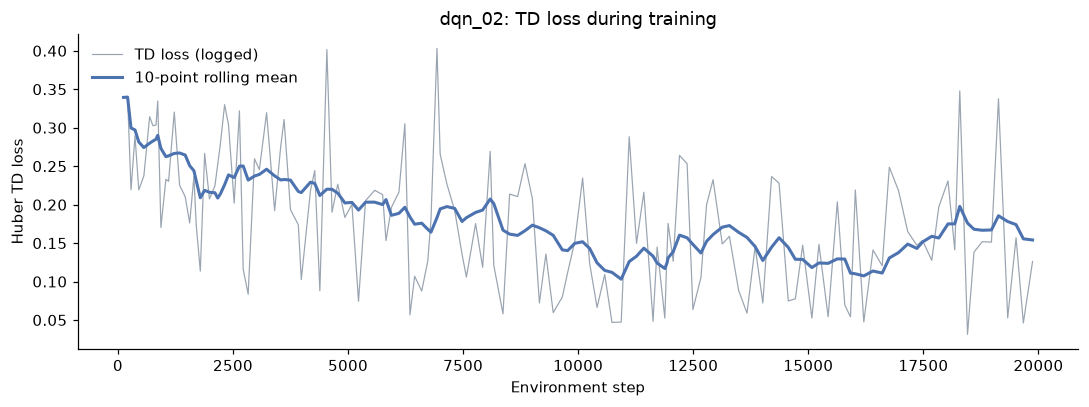

Mean TD loss by quarter of training: [0.246, 0.187, 0.144, 0.146]


,recorded_final_mean_reward,reproduced_final_mean_reward
dqn,9.659,9.659
ppo,7.675,7.675
a2c,5.325,5.325
reinforce,3.078,-0.501


In [15]:
loss = pd.read_csv(ROOT / "logs/stability/dqn_loss.csv")
stab = json.loads((ROOT / "logs/stability/summary.json").read_text())

fig, ax = plt.subplots(figsize=(10, 3.8))
ax.plot(loss["step"], loss["value"], color="#9aa5b1", lw=0.8, label="TD loss (logged)")
ax.plot(loss["step"], loss["value"].rolling(10, min_periods=1).mean(), color="#4c72b0", lw=2,
        label="10-point rolling mean")
ax.set_xlabel("Environment step")
ax.set_ylabel("Huber TD loss")
ax.set_title("dqn_02: TD loss during training")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

quarters = np.array_split(loss["value"].to_numpy(), 4)
print("Mean TD loss by quarter of training:", [round(float(q.mean()), 3) for q in quarters])
pd.DataFrame(stab).T[["recorded_final_mean_reward", "reproduced_final_mean_reward"]]

REINFORCE did not reproduce (3.08 recorded, −0.50 on rerun). Its training loop resets the environment without a seed, so its numbers in Section 4.2 are from a single non-reproducible run. DQN, PPO and A2C reproduce.

### 5.4 Generalization to held-out seeds

The saved `dqn_02` model is evaluated here, in this notebook, on 20 seeds (5000–5019) that no training or tuning run used, acting greedily. A uniform random policy on the same seeds is the baseline. The result is checked against the value logged by `tests/generalization_test.py`.

In [16]:
HELD_OUT_SEEDS = list(range(5000, 5020))


def outcome_of(info):
    return "DROPOUT" if info["dropout"] else "SUCCESS" if info["success"] else "TRUNCATED"


def evaluate(policy_fn, seeds):
    env = AdaptLearnEnv()
    rewards, outcomes, decisions = [], [], []
    for seed in seeds:
        obs, info = env.reset(seed=seed)
        done, total = False, 0.0
        while not done:
            state_before = info["engagement_state"]
            action = policy_fn(obs)
            decisions.append((state_before, ACTION_NAMES[action], obs.copy()))
            obs, reward, terminated, truncated, info = env.step(action)
            total += reward
            done = terminated or truncated
        rewards.append(total)
        outcomes.append(outcome_of(info))
    return np.array(rewards), Counter(outcomes), decisions


dqn_rewards, dqn_outcomes, dqn_decisions = evaluate(
    lambda o: int(model.predict(o, deterministic=True)[0]), HELD_OUT_SEEDS)

rng = np.random.default_rng(0)
rand_rewards, rand_outcomes, _ = evaluate(lambda o: int(rng.integers(8)), HELD_OUT_SEEDS)

logged = json.loads((ROOT / "logs/generalization/results.json").read_text())
logged_dqn = logged["part1_held_out_eval"]["dqn"]

summary = pd.DataFrame({
    "DQN (dqn_02), this notebook": {"mean_reward": dqn_rewards.mean(), "std_reward": dqn_rewards.std(), **dqn_outcomes},
    "DQN (dqn_02), logged": {"mean_reward": logged_dqn["mean_reward"], "std_reward": logged_dqn["std_reward"], **logged_dqn["outcomes"]},
    "Random policy": {"mean_reward": rand_rewards.mean(), "std_reward": rand_rewards.std(), **rand_outcomes},
}).T.fillna(0)
for c in ["SUCCESS", "TRUNCATED", "DROPOUT"]:
    if c not in summary:
        summary[c] = 0
summary[["SUCCESS", "TRUNCATED", "DROPOUT"]] = summary[["SUCCESS", "TRUNCATED", "DROPOUT"]].astype(int)
print("Re-evaluation matches the logged result:", bool(np.allclose(dqn_rewards, logged_dqn["rewards"])))
print(f"Training final mean reward: {best['final_mean_reward']:.2f} | held-out mean reward: {dqn_rewards.mean():.2f}")
summary[["mean_reward", "std_reward", "SUCCESS", "TRUNCATED", "DROPOUT"]]

Re-evaluation matches the logged result: True
Training final mean reward: 9.66 | held-out mean reward: 8.50


,mean_reward,std_reward,SUCCESS,TRUNCATED,DROPOUT
"DQN (dqn_02), this notebook",8.497,4.196,2,15,3
"DQN (dqn_02), logged",8.497,4.196,2,15,3
Random policy,0.232,5.124,0,5,15


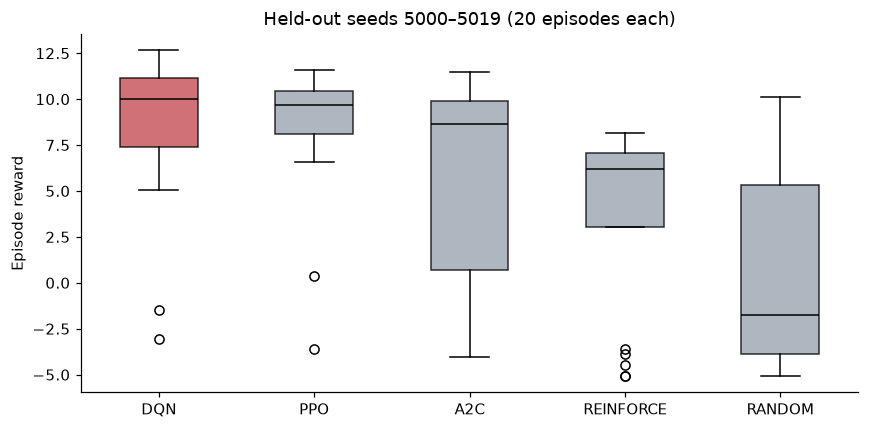

,mean,std,min,max
dqn,8.497,4.196,-3.08,12.65
ppo,8.414,3.684,-3.60,11.58
a2c,5.943,5.374,-4.06,11.45
reinforce,3.881,4.850,-5.06,8.15
random,0.232,5.124,-5.06,10.10


In [17]:
held = pd.DataFrame({a: logged["part1_held_out_eval"][a]["rewards"] for a in ["dqn", "ppo", "a2c", "reinforce"]})
held["random"] = rand_rewards

fig, ax = plt.subplots(figsize=(8, 4))
bp = ax.boxplot([held[c] for c in held.columns], tick_labels=[c.upper() for c in held.columns], patch_artist=True)
for patch, c in zip(bp["boxes"], held.columns):
    patch.set_facecolor("#c44e52" if c == "dqn" else "#9aa5b1")
    patch.set_alpha(0.8)
for med in bp["medians"]:
    med.set_color("black")
ax.set_ylabel("Episode reward")
ax.set_title("Held-out seeds 5000–5019 (20 episodes each)")
plt.tight_layout()
plt.show()
held.agg(["mean", lambda s: s.std(ddof=0), "min", "max"]).T.set_axis(["mean", "std", "min", "max"], axis=1)

Reading this honestly:

- DQN drops from 9.66 (training) to about 8.50 on held-out seeds. Part of that gap is that 9.66 is the best of 12 configurations, so it is an optimistic number.
- DQN and PPO are effectively tied on held-out seeds (8.50 vs 8.41, with standard deviations around 4). Twenty episodes cannot separate them. DQN's lead in Section 4.2 is a training-reward lead.
- Most DQN episodes end by truncation at 50 steps, not by success. The policy keeps the simulated learner out of dropout but rarely completes all eight topics without a single disengaged step, which is a strict bar.

### 5.5 Edge-case starting conditions

Five episodes each from four deliberately extreme starts (logged by `tests/generalization_test.py`). "Sensible first action" uses a hand-written expectation per condition, so treat that column as a sanity check and not as a score.

In [18]:
edge = pd.DataFrame(logged["part2_edge_case_stress_test"]["dqn"]).T
edge["first_actions"] = edge["first_actions"].apply(lambda a: ", ".join(f"{k} ×{v}" for k, v in Counter(a).items()))
edge["outcomes"] = edge["outcomes"].apply(lambda o: ", ".join(f"{k} {v}" for k, v in o.items()))
edge["sensible_first_action"] = edge["n_sensible_first_action"].astype(str) + "/" + edge["n_reps"].astype(str)
edge[["mean_reward", "std_reward", "outcomes", "first_actions", "sensible_first_action"]]

,mean_reward,std_reward,outcomes,first_actions,sensible_first_action
max_gap_engaged,9.01,1.136,TRUNCATED 5,decrease_difficulty ×5,5/5
min_gap_engaged,0.054,3.791,"DROPOUT 4, TRUNCATED 1",advance_topic ×5,5/5
start_frustrated,8.084,3.921,"TRUNCATED 4, DROPOUT 1",add_encouragement ×5,5/5
start_confused,8.466,4.081,"TRUNCATED 3, DROPOUT 1, SUCCESS 1","add_encouragement ×2, advance_topic ×3",0/5


The weak spot is `min_gap_engaged` (task far too easy for the learner): mean reward near zero and four dropouts in five episodes.

### 5.6 What the policy does in each state

This is the nearest thing to a confusion matrix: for each simulated state, how often the trained policy chose each action, over the held-out episodes from Section 5.4.

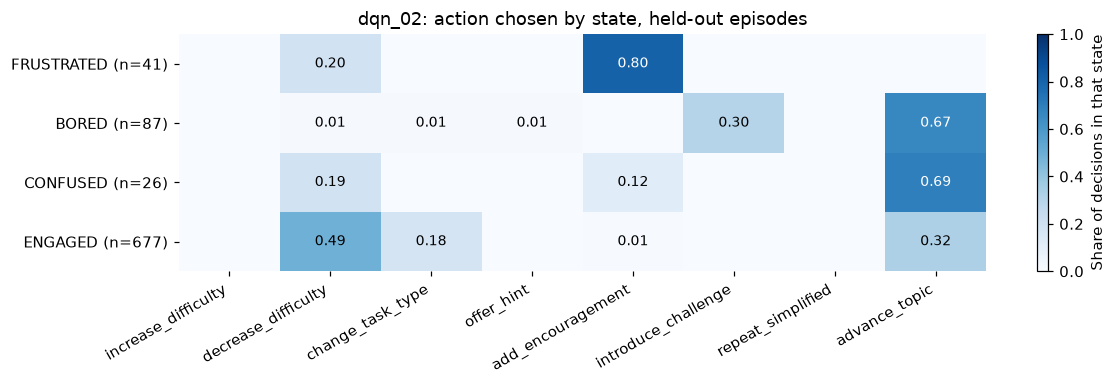

action,increase_difficulty,decrease_difficulty,change_task_type,offer_hint,add_encouragement,introduce_challenge,repeat_simplified,advance_topic
state,,,,,,,,
FRUSTRATED,0,8,0,0,33,0,0,0
BORED,0,1,1,1,0,26,0,58
CONFUSED,0,5,0,0,3,0,0,18
ENGAGED,0,332,121,0,4,0,0,220


In [19]:
dec = pd.DataFrame([(s, a) for s, a, _ in dqn_decisions], columns=["state", "action"])
counts = pd.crosstab(dec["state"], dec["action"]).reindex(index=STATE_NAMES, columns=list(ACTION_NAMES), fill_value=0)
shares = counts.div(counts.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(11, 3.6))
im = ax.imshow(shares, cmap="Blues", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(len(ACTION_NAMES)))
ax.set_xticklabels(ACTION_NAMES, rotation=30, ha="right")
ax.set_yticks(range(4))
ax.set_yticklabels([f"{s} (n={counts.loc[s].sum()})" for s in STATE_NAMES])
for i in range(4):
    for j in range(len(ACTION_NAMES)):
        v = shares.iloc[i, j]
        if v > 0:
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=9, color="white" if v > 0.6 else "black")
fig.colorbar(im, ax=ax, label="Share of decisions in that state")
ax.set_title("dqn_02: action chosen by state, held-out episodes")
ax.spines[:].set_visible(False)
plt.tight_layout()
plt.show()
counts

In [20]:
obs_batch = torch.as_tensor(np.stack([o for _, _, o in dqn_decisions]))
with torch.no_grad():
    q = model.q_net(obs_batch).numpy()
q_df = pd.DataFrame(q, columns=ACTION_NAMES)
q_df["state"] = dec["state"].values
print("Mean Q-value per action, by state, over the observations visited in the held-out episodes:")
with pd.option_context("display.width", 200):
    display(q_df.groupby("state").mean().reindex(STATE_NAMES).round(2))
print(f"Q-value range over all visited observations: {q.min():.2f} to {q.max():.2f}")

Mean Q-value per action, by state, over the observations visited in the held-out episodes:


,increase_difficulty,decrease_difficulty,change_task_type,offer_hint,add_encouragement,introduce_challenge,repeat_simplified,advance_topic
state,,,,,,,,
FRUSTRATED,3.28,4.04,3.61,3.86,4.17,3.79,3.88,3.35
BORED,3.72,3.75,4.15,3.83,4.12,4.09,3.48,4.20
CONFUSED,3.80,4.09,3.96,4.10,4.27,3.97,3.76,4.31
ENGAGED,3.48,3.66,3.64,3.60,3.64,3.60,3.56,3.63


Q-value range over all visited observations: 2.84 to 4.80


Three things stand out:

- **Sensible where the signal is strong.** `FRUSTRATED` is mostly answered with `add_encouragement`, and `BORED` with `advance_topic` or `introduce_challenge`.
- **`CONFUSED` is not handled with the confusion-specific actions.** In the simulator, `offer_hint` and `repeat_simplified` are the two actions that directly lower the chance of staying confused. Across these held-out episodes the policy never chose either in that state. It mostly advanced the topic, which pays a progression bonus, and otherwise lowered difficulty or encouraged. An earlier inspection on different seeds (`tests/manual_policy_inspection.py`) found DQN, PPO and A2C all favouring `decrease_difficulty` for `CONFUSED`. The substitute action varies with the sample, but the pattern is the same. Section 2.4 gives part of the reason: from `CONFUSED`, encouragement and lowering difficulty lead to `ENGAGED` about as often as a hint does, because the chance of engagement is driven mainly by the difficulty–ability gap. So the simulator itself gives the agent little reason to prefer a hint. `CONFUSED` is also the rarest state (Section 2.1) and carries the smallest penalty (−0.2). A targeted reward bonus was tried and reverted because it destabilised three of the four algorithms. This is a limitation of the environment design as much as of the policy.
- **Narrow action repertoire.** `increase_difficulty`, `offer_hint` and `repeat_simplified` are almost never used. The policy has learned to work with five of the eight actions.

The Q-values sit in a narrow, bounded band, with small differences between actions in the same state. They show no sign of divergence, but the small margins also mean some action choices are close calls.

## 6. Limitations and next phase

**What this notebook supports**

- A DQN policy trains stably in the simulator, converges within the 20,000-step budget, and reproduces from its seed.
- On unseen seeds it scores well above a random policy and mostly avoids dropout.

**What it does not support**

- Any claim about real learners. Transition probabilities and telemetry offsets in the simulator are hand-set from theory (flow theory, self-determination theory), not fitted to data.
- A clear ranking of DQN over PPO on held-out performance.
- Good handling of the `CONFUSED` state, of learners who start far above the task level, or use of the full set of eight actions.
- Statistical confidence in individual sweep configurations (one seed each, 20-episode evaluations).

**Next phase**

- Stage 1: a lightweight, interpretable classifier (logistic regression or shallow XGBoost) from real telemetry to a behavioural engagement-risk state, validated against structured teacher observation and learner self-report. Accuracy, precision, recall and F1 will be reported for that model.
- A pilot with 10–20 learners aged 8–14, under IREC approval with guardian consent and learner assent, using anonymised IDs.
- The Stage 2 policy stays frozen. Real telemetry is used to check whether its decisions are plausible, not to retrain it.